**Enrollment No.:240840116064**

**PRACTICAL 5**

**AIM:Analyze datasets using correlation, covariance, outlier detection, and distribution analysis.**

**Step 1: Import Required Libraries**

In [73]:
# Import Libraries.
# Import Pandas Library.
import pandas as pd

# Import NumPy Library.
import numpy as np

# Import Matplot Library.
import matplotlib.pyplot as plt

**Step 2: Create Dataset**

In [74]:
# Create Dataset.
data = {
    "Student_ID": [101,102,103,104,105,106,107,108,109,110,111,112,113,114,115],
    "Study_Hours": [2,3,4,5,6,7,8,9,3,4,5,6,7,10,1],
    "Attendance": [65,70,75,80,82,85,90,92,68,74,78,84,88,95,40],
    "Assignment_Score": [55,60,65,70,72,78,82,88,62,67,71,76,80,95,35],
    "Final_Marks": [50,55,62,68,72,78,82,90,58,63,69,75,81,98,25]
}
df = pd.DataFrame(data)
df

,Student_ID,Study_Hours,Attendance,Assignment_Score,Final_Marks
0,101,2,65,55,50
1,102,3,70,60,55
2,103,4,75,65,62
3,104,5,80,70,68
4,105,6,82,72,72
5,106,7,85,78,78
6,107,8,90,82,82
7,108,9,92,88,90
8,109,3,68,62,58
9,110,4,74,67,63


Step 3: Inspect Dataset

In [75]:
# 3.1: Display first five records.
df.head()

,Student_ID,Study_Hours,Attendance,Assignment_Score,Final_Marks
0,101,2,65,55,50
1,102,3,70,60,55
2,103,4,75,65,62
3,104,5,80,70,68
4,105,6,82,72,72


In [76]:
# 3.2: Display information about the dataset including data-type not null value.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Student_ID        15 non-null     int64
 1   Study_Hours       15 non-null     int64
 2   Attendance        15 non-null     int64
 3   Assignment_Score  15 non-null     int64
 4   Final_Marks       15 non-null     int64
dtypes: int64(5)
memory usage: 732.0 bytes


In [77]:
# 3.3: Display the number of rows and columns.
df.shape

(15, 5)

In [78]:
# 3.4: Generate basic descriptive Stastices.
df.describe()

,Student_ID,Study_Hours,Attendance,Assignment_Score,Final_Marks
count,15.000000,15.000000,15.000000,15.000000,15.000000
mean,108.000000,5.333333,77.733333,70.400000,68.400000
std,4.472136,2.581989,13.718948,14.500246,17.759504
min,101.000000,1.000000,40.000000,35.000000,25.000000
25%,104.500000,3.500000,72.000000,63.500000,60.000000
50%,108.000000,5.000000,80.000000,71.000000,69.000000
75%,111.500000,7.000000,86.500000,79.000000,79.500000
max,115.000000,10.000000,95.000000,95.000000,98.000000


**Step 4: Calculate correlation**

In [79]:
# Calculate the correlation between study hours and final marks.
correlation_study = df['Study_Hours'].corr(df['Final_Marks'])
print(f"Correlation between Study_Hours and Final_Marks: {correlation_study}")

Correlation between Study_Hours and Final_Marks: 0.9626650934516625


**Step 5: Calculate correlation matrix**

In [80]:
# Calculate correlation among all numerical variables.
correlation_matrix = df.corr()
print("Correlation Matrix:")
print(correlation_matrix)

Correlation Matrix:
                    Student_ID  Study_Hours    Attendance  Assignment_Score  \
Student_ID        1.000000e+00     0.247436 -7.279626e-16          0.136585   
Study_Hours       2.474358e-01     1.000000  9.201931e-01          0.961552   
Attendance       -7.279626e-16     0.920193  1.000000e+00          0.981905   
Assignment_Score  1.365851e-01     0.961552  9.819053e-01          1.000000   
Final_Marks       1.286063e-01     0.962665  9.837631e-01          0.999268   

                  Final_Marks  
Student_ID           0.128606  
Study_Hours          0.962665  
Attendance           0.983763  
Assignment_Score     0.999268  
Final_Marks          1.000000  


Step 6: Visualize Correaltion Using Scatter Plot

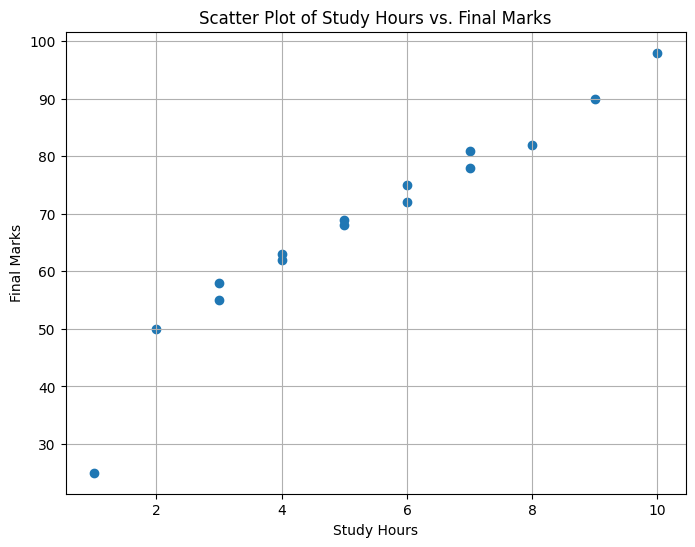

In [81]:
# Create a scatter plot to visualize the realtionship between Study hours and final marks.
plt.figure(figsize=(8, 6))
plt.scatter(df['Study_Hours'], df['Final_Marks'])
plt.title('Scatter Plot of Study Hours vs. Final Marks')
plt.xlabel('Study Hours')
plt.ylabel('Final Marks')
plt.grid(True)
plt.show()

**Step 7: Calculate Covariance**

In [82]:
# Calculate covariance between study hours and final marks.
covariance_study_final = df['Study_Hours'].cov(df['Final_Marks'])
print(f"Covariance between Study_Hours and Final_Marks: {covariance_study_final}")

Covariance between Study_Hours and Final_Marks: 44.14285714285714


**Step 8: Calculate covariance matrix**

In [83]:
# 8.1: Select the numerical columns for covariance analysis.
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

if 'Student_ID' in numerical_cols:
    numerical_cols.remove('Student_ID')
df_numerical = df[numerical_cols]
print("Numerical columns selected for covariance analysis:")
print(numerical_cols)

Numerical columns selected for covariance analysis:
['Study_Hours', 'Attendance', 'Assignment_Score', 'Final_Marks']


In [84]:
# 8.2: Calculate the covariance matrix.
covariance_matrix = df_numerical.cov()
print("Covariance Matrix:")
print(covariance_matrix)

Covariance Matrix:
                  Study_Hours  Attendance  Assignment_Score  Final_Marks
Study_Hours          6.666667   32.595238         36.000000    44.142857
Attendance          32.595238  188.209524        195.328571   239.685714
Assignment_Score    36.000000  195.328571        210.257143   257.328571
Final_Marks         44.142857  239.685714        257.328571   315.400000


**Step 9: Detect Outliers Using IQR (Select the Final marks column for outliers analysis.**

In [85]:
Q1 = df['Final_Marks'].quantile(0.25)  # Calculate the first quartile (Q1)
Q3 = df['Final_Marks'].quantile(0.75)  # Calculate the third quartile (Q3)

IQR = Q3 - Q1  # Interquartile Range (IQR)
lower_bound = Q1 - 1.5 * IQR  # lower limit for detecting outliers
upper_bound = Q3 + 1.5 * IQR  # upper limit for detecting outliers

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")  # Display Q1, Q3 and IQR values
print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")  # Display the lower and upper limits

outliers = df[                                    # Find values that are below the lower bound or above the upper bound
    (df['Final_Marks'] < lower_bound) |
    (df['Final_Marks'] > upper_bound)
]

# Display the detected outliers
print("\nOutliers detected:")
print(outliers)

Q1: 60.0, Q3: 79.5, IQR: 19.5
Lower Bound: 30.75, Upper Bound: 108.75

Outliers detected:
    Student_ID  Study_Hours  Attendance  Assignment_Score  Final_Marks
14         115            1          40                35           25


**Step 10: Identify Outliers**

In [86]:
# Select records where final marks are below thw lower bound or above the upper bound.
outliers = df[(df['Final_Marks'] < lower_bound) | (df['Final_Marks'] > upper_bound)]

print("Outliers:")
print(outliers)

Outliers:
    Student_ID  Study_Hours  Attendance  Assignment_Score  Final_Marks
14         115            1          40                35           25


**Step 11: Count Outliers**

In [87]:
# Count the total number of detected outliers.
num_outliers = len(outliers)
print(f"Total number of detected outliers: {num_outliers}")

Total number of detected outliers: 1


**Step 12: Visualize Outliers Using Box Plot.**

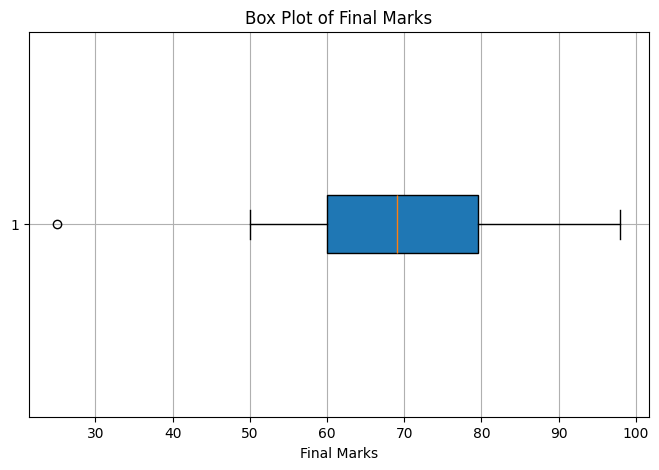

In [88]:
plt.figure(figsize=(8, 5))
plt.boxplot(df['Final_Marks'], vert=False, patch_artist=True)
plt.title('Box Plot of Final Marks')
plt.xlabel('Final Marks')
plt.grid(True)
plt.show()

**Step 13: Create a Histogram**

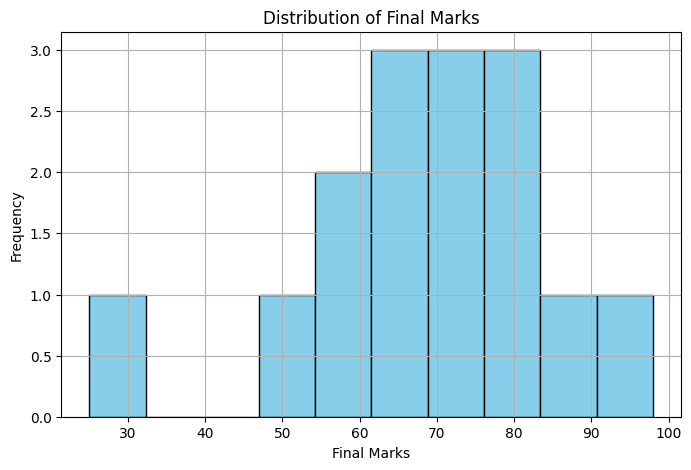

Skewness of Final Marks: -0.7383380071904277


In [89]:
# Create a histogram to observe the distribution of final marks.
plt.figure(figsize=(8, 5))
plt.hist(df['Final_Marks'], bins=10, edgecolor='black', color='skyblue')
plt.title('Distribution of Final Marks')
plt.xlabel('Final Marks')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

skewness_final_marks = df['Final_Marks'].skew()
print(f"Skewness of Final Marks: {skewness_final_marks}")

**Step 14: Analyze distribution using skewness**

In [90]:
# Calculate the skewness of final marks.
skewness_final_marks = df['Final_Marks'].skew()
print(f"Skewness of Final Marks: {skewness_final_marks}")

Skewness of Final Marks: -0.7383380071904277


**Step 15: Calculate Kurtosis**

In [91]:
# Calculate the kurtosis of final marks.
kurtosis_final_marks = df['Final_Marks'].kurtosis()
print(f"Kurtosis of Final Marks: {kurtosis_final_marks}")

Kurtosis of Final Marks: 1.4936683306648835


**Step 16: Distribution of Study hours(Create a histogram for study hours.)**

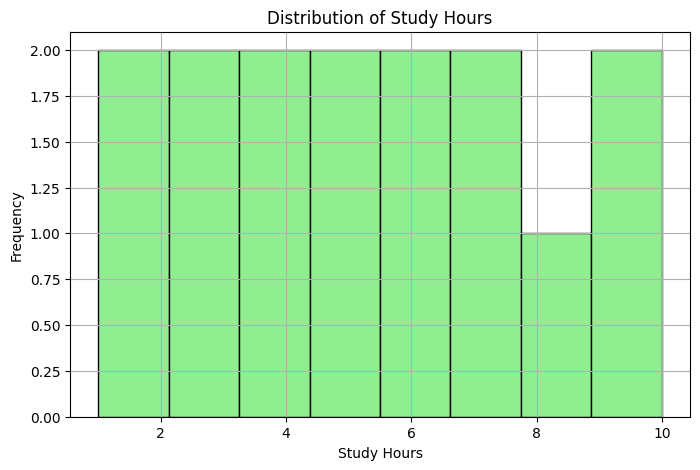

In [92]:
# Create a histogram for study hours.
plt.figure(figsize=(8, 5))
plt.hist(df['Study_Hours'], bins=8, edgecolor='black', color='lightgreen')
plt.title('Distribution of Study Hours')
plt.xlabel('Study Hours')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

**Step 17: Compare variables using box plots**

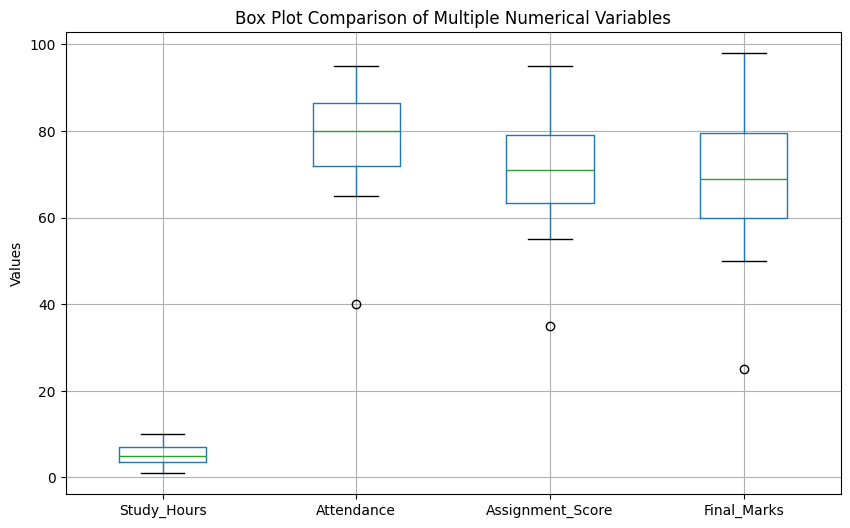

In [93]:
# Create box plots for muktiple numercial variables.
plt.figure(figsize=(10, 6))
df[['Study_Hours', 'Attendance', 'Assignment_Score', 'Final_Marks']].boxplot()
plt.title('Box Plot Comparison of Multiple Numerical Variables')
plt.ylabel('Values')
plt.grid(True)
plt.show()

**Step 18: Generate a Statistical Summary**

In [94]:
df.describe()

,Student_ID,Study_Hours,Attendance,Assignment_Score,Final_Marks
count,15.000000,15.000000,15.000000,15.000000,15.000000
mean,108.000000,5.333333,77.733333,70.400000,68.400000
std,4.472136,2.581989,13.718948,14.500246,17.759504
min,101.000000,1.000000,40.000000,35.000000,25.000000
25%,104.500000,3.500000,72.000000,63.500000,60.000000
50%,108.000000,5.000000,80.000000,71.000000,69.000000
75%,111.500000,7.000000,86.500000,79.000000,79.500000
max,115.000000,10.000000,95.000000,95.000000,98.000000


**Step 19: Save the Analysis Dataset**

In [95]:
# Save the updated dataset contaning revenue growth as a CSV file.
df.to_csv('Dataset_analysis.csv', index=False)
print("Dataset saved successfully as 'Dataset_analysis.csv'")

Dataset saved successfully as 'Dataset_analysis.csv'


**Step 20: Download the CSV in Google colab**

In [96]:
# Import the files module from Google colab.
from google.colab import files

# Download the CSV file.
files.download("Dataset_analysis.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>